# 03 — Rain–Flow Event Matching

Links every flow event to its driving rain window by walking backward/forward
from the flow start/end until all stations are dry.

Produces a MultiIndex DataFrame with:
- Discharge metrics (peak Q, volume, runoff depth)
- Per-station rain stats (total mm, max intensity at every duration, runoff coefficient)
- Season-based event IDs (e.g. 101, 201 …)

**Requires:** outputs of notebooks 01 and 02  
**Output:** `flow_rain_events.csv`

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import config as cfg
from utils.discharge import assign_season_id
from utils.matching import build_rainflow_table, filter_by_total_rain

## 1  Load data

In [2]:
# ── Rain (indexed by datetime) ────────────────────────────────────────────────
def load_rain(path):
    df = pd.read_csv(path, parse_dates=['date_time'])
    df['date_time'] = df['date_time'].dt.tz_localize(None)
    return df.sort_values('date_time').set_index('date_time')

gv_rain  = load_rain(cfg.GV_PROC_CSV)
ziv_rain = load_rain(cfg.ZIV_PROC_CSV)
ram_rain = load_rain(cfg.RAM_PROC_CSV)

rain_dfs = [gv_rain, ziv_rain, ram_rain]
print('Rain data loaded.')

Rain data loaded.


In [3]:
# ── Flow events ────────────────────────────────────────────────────────────────
fe = pd.read_csv(cfg.FLOW_EVENTS_CSV)
fe['flow_start'] = pd.to_datetime(fe['flow_start_date'] + ' ' + fe['flow_start_time'],
                                   dayfirst=True, errors='coerce')
fe['flow_end']   = pd.to_datetime(fe['flow_end_date']   + ' ' + fe['flow_end_time'],
                                   dayfirst=True, errors='coerce')
fe['flow_peak_datetime'] = pd.to_datetime(
    fe['flow_peak_date'].astype(str) + ' ' + fe['flow_peak_time'].astype(str),
    dayfirst=True, errors='coerce'
)
fe = fe.drop(columns=['flow_start_date', 'flow_start_time',
                       'flow_end_date',   'flow_end_time',
                       'flow_peak_date',  'flow_peak_time']).dropna(subset=['flow_start', 'flow_end'])
print(f'Loaded {len(fe)} flow events.')
fe.head()

Loaded 61 flow events.


,flow_peak_m3_s,flow_total_volume_m3,flow_start,flow_end,flow_peak_datetime
0,0.617218,1773.301946,2023-11-01 12:20:00,2023-11-03 11:00:00,2023-11-01 13:50:00
1,0.063550,39.911987,2023-11-14 16:30:00,2023-11-14 17:05:00,2023-11-14 16:40:00
2,0.394052,7530.163635,2023-11-19 14:20:00,2023-11-21 16:15:00,2023-11-20 02:55:00
3,0.218358,2319.086856,2023-11-27 04:05:00,2023-11-27 18:10:00,2023-11-27 13:30:00
4,0.166977,545.809527,2023-12-05 16:20:00,2023-12-06 12:40:00,2023-12-05 17:50:00


## 2  Build MultiIndex rain–flow table

In [4]:
raw_df = build_rainflow_table(
    flow_events=fe,
    rain_dfs=rain_dfs,
    station_names=cfg.STATION_KEYS,
    area_km2=cfg.CATCHMENT_AREA_KM2,
)
print(f'Built table: {len(raw_df)} events × {len(raw_df.columns)} columns')

Built table: 61 events × 67 columns


## 3  Filter dry events and assign season IDs

In [5]:
matched_df = filter_by_total_rain(raw_df, cfg.STATION_KEYS, cfg.TOTAL_RAIN_THRESHOLD_MM)
print(f'Dropped {len(raw_df) - len(matched_df)} dry events  |  Kept {len(matched_df)}')

flow_start_series = matched_df[('discharge', 'flow_start')]
matched_df['season_index'] = assign_season_id(
    pd.DataFrame({'flow_start': flow_start_series})
)
matched_df = matched_df.set_index('season_index')
matched_df.index = matched_df.index.astype('Int64')
print('Season IDs assigned.')

Dropped 15 dry events  |  Kept 46
Season IDs assigned.


## 4  Save

In [6]:
matched_df.to_csv(cfg.FLOW_RAIN_CSV)
print(f'Saved {len(matched_df)} events → {cfg.FLOW_RAIN_CSV}')

Saved 46 events → D:\Development\RESEARCH\Gazelle_Valley\Data\discharge\flow_rain_events.csv


## 5  Runoff coefficient distribution

Gazelle Valley: median C = 0.075
Ziv: median C = 0.087
Givat Ram: median C = 0.089


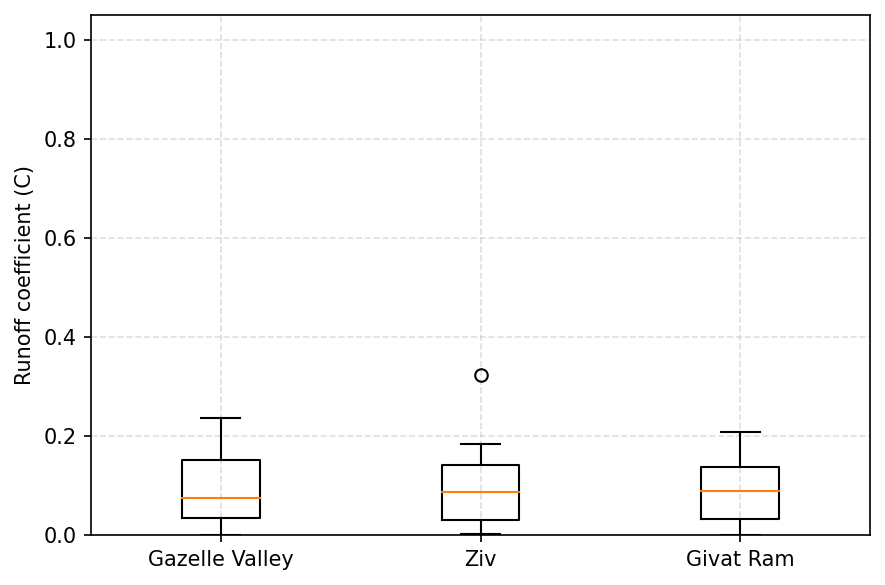

In [7]:
data  = [pd.to_numeric(matched_df[(s, 'runoff_co')], errors='coerce').dropna().values
         for s in cfg.STATION_KEYS]
labels = [cfg.STATIONS[s]['label'] for s in cfg.STATION_KEYS]

for s, d in zip(labels, data):
    if len(d):
        print(f'{s}: median C = {np.median(d):.3f}')

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.boxplot(data, labels=labels, showfliers=True)
ax.set_ylabel('Runoff coefficient (C)')
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()

## 6  Peak flow vs. rain metrics

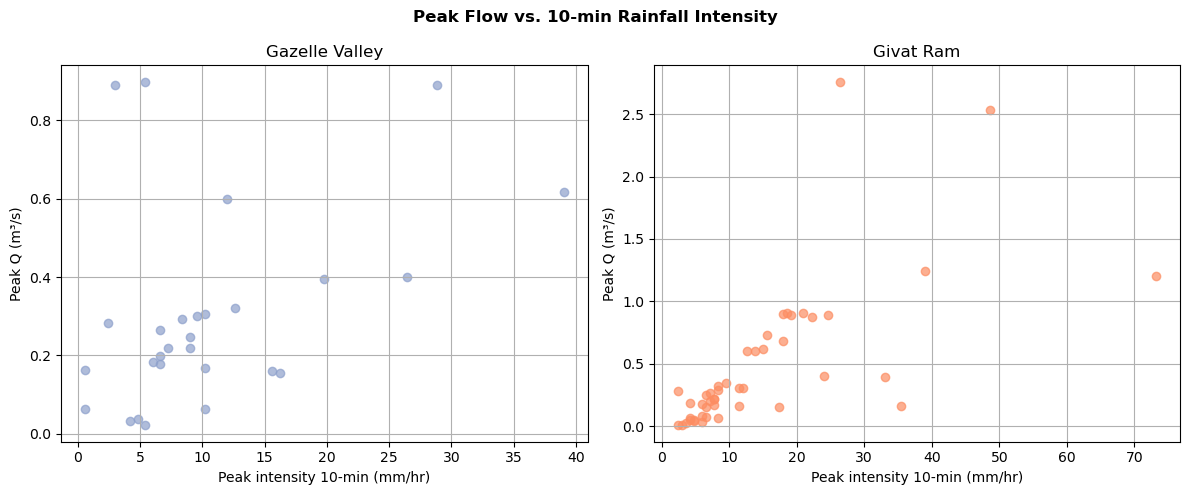

In [8]:
q_peak = matched_df[('discharge', 'flow_peak_m3_s')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, station in zip(axes, ['gazelle_valley', 'givat_ram']):
    intens = matched_df[(station, 'max_rain_intens_10min_mm_hr')]
    valid  = q_peak.notna() & intens.notna()
    ax.scatter(intens[valid], q_peak[valid],
               color=cfg.STATIONS[station]['color'], alpha=0.7)
    ax.set_xlabel('Peak intensity 10-min (mm/hr)')
    ax.set_ylabel('Peak Q (m³/s)')
    ax.set_title(cfg.STATIONS[station]['label'])
    ax.grid(True)
fig.suptitle('Peak Flow vs. 10-min Rainfall Intensity', fontweight='bold')
fig.tight_layout()
plt.show()

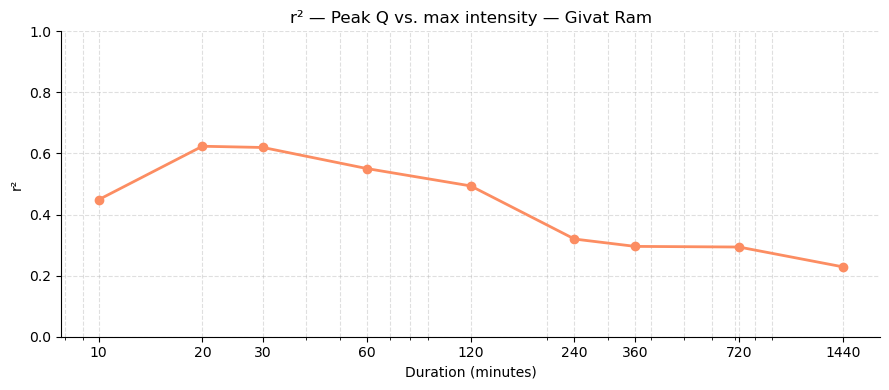

In [9]:
# r² of peak Q vs. rainfall metrics across all durations
station = 'givat_ram'
intens_cols = [c for c in matched_df[station].columns
               if isinstance(c, str) and c.startswith('max_rain_intens_') and c.endswith('mm_hr')]
durations   = sorted(int(c.replace('max_rain_intens_','').replace('min_mm_hr',''))
                     for c in intens_cols)

r2_vals = []
for dur in durations:
    col   = (station, f'max_rain_intens_{dur}min_mm_hr')
    intens = matched_df[col].astype(float)
    mask   = q_peak.notna() & intens.notna()
    if mask.sum() >= 3:
        r = q_peak[mask].corr(intens[mask])
        r2_vals.append(r**2 if pd.notna(r) else np.nan)
    else:
        r2_vals.append(np.nan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(durations, r2_vals, marker='o', color=cfg.STATIONS[station]['color'], linewidth=2)
ax.set_xscale('log')
ax.set_xticks(durations)
ax.set_xticklabels(durations)
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('r²')
ax.set_ylim(0, 1)
ax.set_title(f'r² — Peak Q vs. max intensity — {cfg.STATIONS[station]["label"]}')
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
plt.show()

## 7  Rain events without associated flow

In [10]:
rain_events = pd.read_csv(cfg.RAIN_EVENTS_RAM_CSV,
                           parse_dates=['rain_event_start', 'rain_event_end'])
rain_events['rain_event_start'] = rain_events['rain_event_start'].dt.tz_localize(None)

re_starts = matched_df[('rain', 'rain_event_start')]
re_ends   = matched_df[('rain', 'rain_event_end')]

unmatched = []
for _, row in rain_events.iterrows():
    rs = row['rain_event_start']
    covered = ((re_starts <= rs) & (re_ends >= rs)).any()
    if not covered:
        unmatched.append(row)

unmatched_df = pd.DataFrame(unmatched)
print(f"Total rain events    : {len(rain_events)}")
print(f"With associated flow : {len(rain_events) - len(unmatched_df)}")
print(f"No associated flow   : {len(unmatched_df)}")
unmatched_df[['rain_event_start', 'rain_event_end', 'total_rain_mm']]

Total rain events    : 99
With associated flow : 82
No associated flow   : 17


,rain_event_start,rain_event_end,total_rain_mm
6,2023-12-09 00:20:00,2023-12-09 00:40:00,1.3
22,2024-02-15 14:40:00,2024-02-15 14:50:00,1.3
28,2024-03-07 02:10:00,2024-03-07 11:30:00,1.0
30,2024-04-10 02:20:00,2024-04-10 12:10:00,5.0
34,2024-11-18 07:00:00,2024-11-18 10:30:00,0.8
37,2024-11-27 21:30:00,2024-11-28 07:20:00,2.7
44,2025-01-23 01:00:00,2025-01-23 15:20:00,3.1
47,2025-02-12 12:10:00,2025-02-13 07:00:00,5.5
56,2025-03-29 05:00:00,2025-03-29 11:00:00,1.1
57,2025-04-06 15:00:00,2025-04-06 15:10:00,0.8
